In [20]:
from embedding.product_embedder import ProductEmbedder
from embedding.customer_embedder import CustomerEmbedder
from manager.embedding_manager import EmbeddingManager
from utils import load_transactions, half_life_decay, top_categories_for_customer, top_subcategories_for_customer,get_customer_orders_summary, build_behavioral_cluster_profiles, category_stats_list,normalize_category_and_subcategory_inplace, basic_clean

import os
import numpy as np
import pandas as pd

In [21]:
product = ProductEmbedder(
    model_name="paraphrase-MiniLM-L6-v2"
)
manager = EmbeddingManager(
    product_csv_path="../../data/enriched_cache.csv",
    embedding_pkl_path="../../data/products_with_embeddings.pkl",
    collection_name="products"
)
customer = CustomerEmbedder(
    enriched_data_path="../../data/enriched_retail.csv",
    product_embedding_path="../../data/products_with_embeddings.pkl",
    output_path="../data/customer_embeddings.pkl",  # finansal olanın varsayılanı
)

In [23]:
query = "red  backpack"  
results = manager.query_similar_products(query_text=query, top_k=4)
enriched = manager.enrich_search_results(results)
pd.DataFrame(enriched)



/Users/mustafadoganozgun/PycharmProjects/product-enrichment-agent/.venv/lib/python3.12/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


,StockCode,Description,Score
0,20669,RED HEART LUGGAGE TAG,41.793571
1,23388,WOODLAND MINI BACKPACK,41.453758
2,23389,SPACEBOY MINI BACKPACK,38.425709
3,23438,RED SPOT GIFT BAG LARGE,36.961586


In [15]:
# Sadece davranış temelli (para YOK) müşteri embeddingleri:
df_behavioral = customer.generate_behavioral_embeddings(
    half_life_days=365,   # 1 yıl yarı ömür
    normalize=True,       # tercih dağılımı gibi yorumlanabilsin
    output_path="../../data/customer_embeddings_behavioral.pkl"  # opsiyonel   
)


⚠️ Overwriting existing file at /Users/mustafadoganozgun/PycharmProjects/product-enrichment-agent/data/customer_embeddings_behavioral.pkl
✅ Behavioral (micro-segment) embeddings saved to /Users/mustafadoganozgun/PycharmProjects/product-enrichment-agent/data/customer_embeddings_behavioral.pkl (rows=4362)


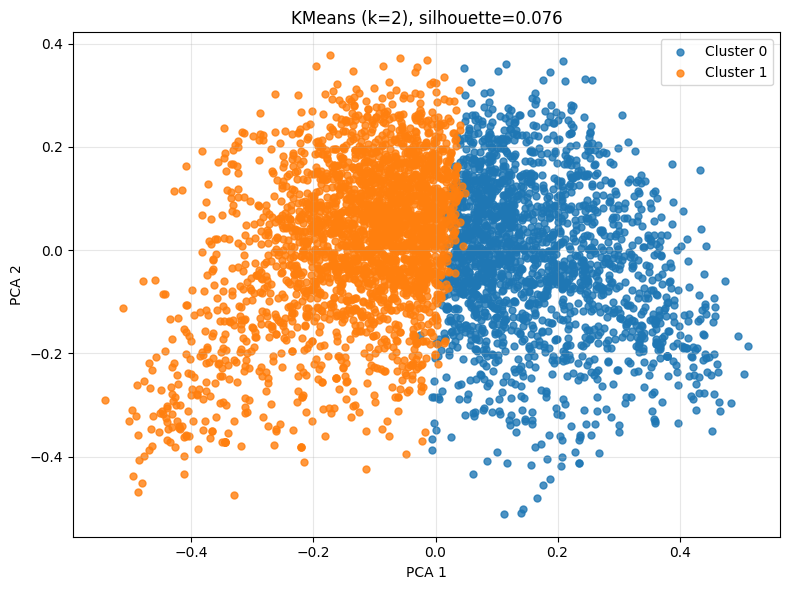

,CustomerID,Days_Since_Last_Purchase,Total_Transactions,Total_Products_Purchased,Total_Spend,Average_Transaction_Value,Unique_Products_Purchased,Average_Days_Between_Purchases,Day_Of_Week,Cancellation_Frequency,Cancellation_Rate,Monthly_Spending_Mean,Monthly_Spending_Std,Spending_Trend,FinancialCluster_KMeans_k3,BehavioralCluster_KMeans_k3,BehavioralCluster_KMeans_k2
0,12346,325,2,0,0.00,0.000000,1,0.000000,1,1.0,0.500000,0.000000,0.000000,0.000000,0,1,0
1,12347,2,7,2458,4310.00,615.714286,103,2.016575,1,0.0,0.000000,615.714286,341.070789,4.486071,2,2,1
2,12348,75,4,2332,1437.24,359.310000,21,10.884615,3,0.0,0.000000,359.310000,203.875689,-100.884000,1,2,1
3,12349,18,1,630,1457.55,1457.550000,72,0.000000,0,0.0,0.000000,1457.550000,0.000000,0.000000,1,2,1
4,12350,310,1,196,294.40,294.400000,16,0.000000,2,0.0,0.000000,294.400000,0.000000,0.000000,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4357,18280,277,1,45,180.60,180.600000,10,0.000000,0,0.0,0.000000,180.600000,0.000000,0.000000,0,2,1
4358,18281,180,1,54,80.82,80.820000,7,0.000000,6,0.0,0.000000,80.820000,0.000000,0.000000,0,1,1
4359,18282,7,3,98,176.60,58.866667,12,9.916667,4,1.0,0.333333,88.300000,14.792674,-20.920000,0,2,1
4360,18283,3,16,1360,2048.63,128.039375,262,0.463245,3,0.0,0.000000,204.863000,167.038863,22.264424,1,1,1


In [16]:
manager.attach_behavioral_microsegments(reports_csv_path = "../../data/customer_reports.csv", behavioral_embeddings_pkl="../../data/customer_embeddings_behavioral.pkl",out_csv_path= None )

In [7]:
df_enriched = pd.read_csv("../../data/enriched_retail.csv")
# Müşteri 12346 için en popüler 5 kategori (adet * decay ile)
top_cat = top_categories_for_customer(df_enriched, customer_id="17850", n=5, half_life_days=365)
print(top_cat)

# Aynı müşterinin en popüler 3 alt kategori (saf sayım)
top_sub = top_subcategories_for_customer(df_enriched, customer_id="17850", n=3, use_quantity=False)
print(top_sub)

                  category        score  count  rank
0            Home & Living  1217.557661    251     1
1  fashion and accessories   299.359708     56     2
2                      NaN     0.000000      2     3
          sub_category  score  count  rank
0  warmers and comfort   69.0     69     1
1            tableware   61.0     61     2
2  candles and holders   36.0     36     3


In [8]:
orders = get_customer_orders_summary(17850, df_enriched)

CustomerID 17850 için toplam harcama: 5303.48

Sipariş bazlı toplamlar:
InvoiceNo
536365     139.12
536366      22.20
536372      22.20
536373     259.86
536375     259.86
536377      22.20
536396     376.36
536399      22.20
536406     353.14
536407      22.20
536600     251.62
536601      22.20
536602     163.76
536603      22.20
536609     244.46
536610      22.20
536612     206.76
536614      22.20
536628     230.56
536629      22.20
536630     244.46
536631      22.20
536685     380.46
536688      22.20
536690     331.26
536693      22.20
536750     434.80
536751      22.20
536752     390.66
536753      22.20
536787     192.46
536789      22.20
536790     532.01
536791      44.40
C543611    -87.73
Name: LineTotal, dtype: float64

En çok harcama yapılan ürünler:
Description
IVORY EMBROIDERED QUILT                607.75
GLASS STAR FROSTED T-LIGHT HOLDER      432.80
WHITE METAL LANTERN                    413.58
KNITTED UNION FLAG HOT WATER BOTTLE    372.90
RED WOOLLY HOTTIE WHITE HEA

In [10]:
# def attach_top_category_features(
#     reports_csv_path: str,
#     orders_csv_path: str,
#     out_csv_path: str | None = None,
#     use_quantity: bool = True,
#     half_life_days: int | None = None,
#     category_col: str = "category",
#     subcategory_col: str = "sub_category",
#     qty_col: str = "Quantity",
#     fallback_to_description: bool = True,   # <— yeni: kategori yoksa Description kullan
# ) -> pd.DataFrame:
#     if not os.path.exists(reports_csv_path):
#         raise FileNotFoundError(f"reports_csv_path not found: {reports_csv_path}")
#     if not os.path.exists(orders_csv_path):
#         raise FileNotFoundError(f"orders_csv_path not found: {orders_csv_path}")
# 
#     # 1) Yükleme
#     df_rep = load_transactions(reports_csv_path)
#     df_ord = load_transactions(orders_csv_path)
# 
#     if "CustomerID" not in df_rep.columns:
#         raise ValueError("reports_csv must contain 'CustomerID' column.")
#     df_rep["CustomerID"] = df_rep["CustomerID"].astype(str)
#     if "CustomerID" not in df_ord.columns:
#         raise ValueError("orders_csv must contain 'CustomerID' column.")
#     df_ord["CustomerID"] = df_ord["CustomerID"].astype(str)
# 
#     # 2) Ağırlıklar
#     if use_quantity and qty_col in df_ord.columns:
#         w = np.clip(df_ord[qty_col].astype(float), 0.0, None)
#     else:
#         w = pd.Series(1.0, index=df_ord.index)
# 
#     if half_life_days is not None:
#         if "InvoiceDate" in df_ord.columns:
#             decay = half_life_decay(df_ord["InvoiceDate"], half_life_days)
#             w = w * pd.Series(decay, index=df_ord.index)
#         else:
#             # tarih yoksa sessizce zaman çürümesini atla
#             pass
# 
#     df_ord = df_ord.copy()
#     df_ord["_w"] = w.values
# 
#     # 3) Kategori fallback
#     have_cat = category_col in df_ord.columns and df_ord[category_col].notna().any()
#     have_sub = subcategory_col in df_ord.columns and df_ord[subcategory_col].notna().any()
#     # eğer yoksa ve izin verildiyse Description’a fallback
#     if fallback_to_description:
#         if not have_cat:
#             if "Description" in df_ord.columns:
#                 df_ord[category_col] = df_ord["Description"].astype(str)
#                 have_cat = True
#         if not have_sub:
#             if "Description" in df_ord.columns:
#                 df_ord[subcategory_col] = df_ord["Description"].astype(str)
#                 have_sub = True
# 
#     # 4) TopCategory
#     if have_cat:
#         cat_scores = (
#             df_ord.groupby(["CustomerID", category_col], dropna=False)["_w"]
#                   .sum().reset_index(name="score")
#         )
#         idx = cat_scores.groupby("CustomerID")["score"].idxmax()
#         top_cat = cat_scores.loc[idx, ["CustomerID", category_col]] \
#                             .rename(columns={category_col: "TopCategory"})
#     else:
#         top_cat = pd.DataFrame(columns=["CustomerID", "TopCategory"])
# 
#     # 5) TopSubCategory
#     if have_sub:
#         subcat_scores = (
#             df_ord.groupby(["CustomerID", subcategory_col], dropna=False)["_w"]
#                   .sum().reset_index(name="score")
#         )
#         idx2 = subcat_scores.groupby("CustomerID")["score"].idxmax()
#         top_subcat = subcat_scores.loc[idx2, ["CustomerID", subcategory_col]] \
#                                   .rename(columns={subcategory_col: "TopSubCategory"})
#     else:
#         top_subcat = pd.DataFrame(columns=["CustomerID", "TopSubCategory"])
# 
#     # 6) Merge ve özet
#     before = len(df_rep)
#     df_out = df_rep.merge(top_cat, on="CustomerID", how="left") \
#                    .merge(top_subcat, on="CustomerID", how="left")
# 
#     filled_topcat = df_out["TopCategory"].notna().sum() if "TopCategory" in df_out.columns else 0
#     filled_subcat = df_out["TopSubCategory"].notna().sum() if "TopSubCategory" in df_out.columns else 0
#     # Basit bir özet mesajı (optional)
#     print(f"TopCategory dolu: {filled_topcat}/{before} | TopSubCategory dolu: {filled_subcat}/{before}")
# 
#     # 7) Kaydet
#     if out_csv_path is None:
#         out_csv_path = reports_csv_path  # üzerine yaz
#     os.makedirs(os.path.dirname(os.path.abspath(out_csv_path)), exist_ok=True)
#     df_out.to_csv(out_csv_path, index=False)
#     return df_out

TopCategory_x,TopSubCategory_x,TopCategory_y,TopSubCategory_y,BehavioralCluster_KMeans_k3,TopCategory,TopSubCategory

In [12]:
df_customer_reports = pd.read_csv("../../data/customer_reports.csv")
df_customer_reports.head

<bound method NDFrame.head of       CustomerID  Days_Since_Last_Purchase  Total_Transactions  \
0          12346                       325                   2   
1          12347                         2                   7   
2          12348                        75                   4   
3          12349                        18                   1   
4          12350                       310                   1   
...          ...                       ...                 ...   
4357       18280                       277                   1   
4358       18281                       180                   1   
4359       18282                         7                   3   
4360       18283                         3                  16   
4361       18287                        42                   3   

      Total_Products_Purchased  Total_Spend  Average_Transaction_Value  \
0                            0         0.00                   0.000000   
1                         245

In [45]:
# df_final = attach_top_category_features(
#     reports_csv_path="../../data/customer_reports.csv",
#     orders_csv_path="../../data/orders_clean.csv",  # sipariş/işlem verin
#     out_csv_path=None,             # None -> mevcut rapor dosyasının üstüne yazar
#     use_quantity=True,             # skorlar Quantity ile ağırlıklandırılsın
#     half_life_days=365             # istersen kaldır (None) -> zaman ağırlığı yok
# )


MergeError: Passing 'suffixes' which cause duplicate columns {'TopCategory_x'} is not allowed.

In [10]:
profiles_df = build_behavioral_cluster_profiles()
print(profiles_df.head())

   cluster                                           label  \
0        0  Home & Living & fashion and accessories Odaklı   
1        1  Home & Living & fashion and accessories Odaklı   
2        2         Home & Living & Kitchen & Dining Odaklı   

                                      top_categories  \
0  Home & Living, fashion and accessories, Kitche...   
1  Home & Living, fashion and accessories, Kitche...   
2  Home & Living, Kitchen & Dining, fashion and a...   

        top_categories_weights  \
0   253229.5, 25660.7, 15944.8   
1    78419.9, 60295.6, 37478.9   
2  335788.7, 210372.0, 73971.0   

                                  top_sub_categories  \
0  decorative ornaments, candles and holders, doo...   
1  bags, storage and containers, napkins and tissues   
2   baking and cooking, storage and containers, bags   

   top_sub_categories_weights  diversity_entropy  freshness_mean_days  \
0   41536.2, 39031.2, 38884.8             1.0125                132.5   
1   66428.6, 44041

In [13]:
df_customer_reports[df_customer_reports["BehavioralCluster_KMeans_k3"] == 0]


NameError: name 'df_customer_reports' is not defined

In [3]:
# df = pd.read_csv("../../data/orders_clean.csv")
# unique_categories = df["category"].unique()
# unique_subcategories = df["sub_category"].unique()
# 
# print("Kategori listesi:", unique_categories)
# print("Alt kategori listesi:", unique_subcategories)

Kategori listesi: ['home decor' 'home goods' 'personal accessories' 'accessories' 'toys'
 'toys & games' 'home & kitchen' 'kitchen & dining' 'stationery'
 'educational supplies' 'kitchenware' 'fashion' 'arts & crafts' 'clothing'
 'hobby & craft' 'health & wellness' 'party supplies' 'home & living'
 'home organization' 'home improvement' 'mutfak & sofra' 'office supplies'
 'kitchen' 'craft supplies' 'hobbies' 'ev dekorasyonu' 'personal care'
 'health & beauty' 'sports & outdoors' 'games & toys' 'food & beverage'
 'pet supplies' 'ev gereçleri' 'electronics' 'gardening' 'kişisel bakım'
 'bath & beauty' 'gift supplies' 'musical instruments' 'kırtasiye'
 'parti malzemeleri' 'jewelry' 'kids' 'travel' 'fashion accessories'
 'hobi malzemeleri' 'crafts' 'home & garden' 'travel accessories']
Alt kategori listesi: ['candle holder' 'lantern' 'coat hanger' 'hot water bottle'
 'nesting dolls' 'hand warmer' 'ornament' 'playset' 'kitchen set' 'doll'
 'mug cosy' 'teaspoon' 'puzzle' 'blocks' 'decorative

In [4]:
# stats = category_stats_list(df)  # siparişlerin olduğu DataFrame
# stats[:5]  # ilk 5 kategori özeti

[{'category': 'home decor',
  'unique_orders': 15704,
  'unique_customers': 3815,
  'total_items': 751201,
  'total_spend': 1845756.95},
 {'category': 'kitchen & dining',
  'unique_orders': 6581,
  'unique_customers': 2050,
  'total_items': 255503,
  'total_spend': 314947.81},
 {'category': 'accessories',
  'unique_orders': 6372,
  'unique_customers': 2101,
  'total_items': 121640,
  'total_spend': 291728.68},
 {'category': 'home goods',
  'unique_orders': 2935,
  'unique_customers': 1200,
  'total_items': 41281,
  'total_spend': 119065.59},
 {'category': 'toys & games',
  'unique_orders': 3545,
  'unique_customers': 1561,
  'total_items': 67474,
  'total_spend': 105594.97}]

In [3]:
df = pd.read_csv("../../data/enriched_retail.csv")
df = normalize_category_and_subcategory_inplace(df)
df.to_csv("../../data/enriched_retail.csv", index=False)

In [8]:
print(df["category"].value_counts())


category
nan                             355798
Home & Living                    88117
Kitchen & Dining                 27328
Fashion & Accessories            20500
Toys & Games                     11426
Arts & Crafts                     7730
Health & Personal Care            7069
Stationery & Office Supplies      6151
Party Supplies                    4498
Musical Instruments               1285
Food & Beverage                    622
Travel                             473
Sports & Outdoors                  438
Gift Supplies                      426
Electronics                        336
Gardening                          224
Pet Supplies                       134
Name: count, dtype: int64


In [9]:
print(df["sub_category"].value_counts())


sub_category
nan                       355798
storage and containers     20785
bags                       12140
baking and cooking         11160
door and entryway          10750
                           ...  
soap holder                   77
sideboard                     29
home fragrance                25
applique                      20
tool set                       1
Name: count, Length: 81, dtype: int64


In [10]:

csv_path = "../../data/enriched_cache.csv"   # senin ürün CSV’in
df_cache = pd.read_csv(csv_path)

# kategori + alt kategori normalizasyonu
df_cache = normalize_category_and_subcategory_inplace(
    df_cache,
    category_col="category",
    subcategory_col="sub_category"
)
df_cache.to_csv("../../data/enriched_cache.csv", index=False)

In [6]:
df_cache.head()

,enrichment_id,category,sub_category,usage_context,price_segment,material_type,target_gender,target_age_group,tags,Description
0,0,Home & Living,candles and holders,decoration,low,ceramic,unisex,adults,"['hanging decoration', 'heart shaped', 't-ligh...",WHITE HANGING HEART T-LIGHT HOLDER
1,1,Home & Living,lighting,decoration,mid,metal,unisex,adults,"['lighting', 'garden', 'patio', 'candle holder...",WHITE METAL LANTERN
2,2,Home & Living,wall decor and hooks,bedroom,mid,wood,female,adults,"['hearts', 'cupid', 'wall hook', 'organizer', ...",CREAM CUPID HEARTS COAT HANGER
3,3,Home & Living,warmers and comfort,gift,mid,knitted fabric,unisex,all ages,"['hot water bottle', 'knitted', 'union flag', ...",KNITTED UNION FLAG HOT WATER BOTTLE
4,4,Home & Living,warmers and comfort,home,low,wool,unisex,all ages,"['hot water bottle', 'warmth', 'comfort', 'win...",RED WOOLLY HOTTIE WHITE HEART.


ValueError: 'StockCode' kolonu bulunamadı.

In [14]:
df = pd.read_csv("../../data/Online Retail.csv")

In [17]:
df = basic_clean(df)

In [18]:
out_pkl = "../../data/products_with_embeddings.pkl"  # hedef cache

product.generate_and_cache_embeddings(
    df=df,
    out_pkl_path=out_pkl,
    id_col="StockCode",
    text_cols=None,               # None -> util.DEFAULT_TEXT_COLS kullanılır
    tags_col="tags",
    store_text_col="embedding_text",
    store_vec_col="embedding",
    keep_existing=False,           # var olanları KORUR, sadece yeni kayıtları ekler
    batch_size=64,                # ister artır
    show_progress=True,
    sort_output=True
)

Batches:   0%|          | 0/62 [00:00<?, ?it/s]/Users/mustafadoganozgun/PycharmProjects/product-enrichment-agent/.venv/lib/python3.12/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
Batches: 100%|██████████| 62/62 [00:02<00:00, 22.34it/s]


'../../data/products_with_embeddings.pkl'

In [4]:
from embedding.milvus_client import MilvusClient
out_pkl = "../../data/products_with_embeddings.pkl"  # hedef cache

milvus = MilvusClient(host="localhost", port="19530", collection_name="products")

# koleksiyon yoksa oluştur
milvus.create_collection(dim=384)  # MiniLM-L6-v2 => 384

# pickle’dan yükle ve Milvus’a bas
cached = pd.read_pickle(out_pkl)
cached["embedding"] = cached["embedding"].apply(lambda x: x.tolist() if hasattr(x, "tolist") else x)
milvus.insert_embeddings(
    product_ids=cached["StockCode"].astype(str).tolist(),
    embeddings=cached["embedding"].tolist()
)

# index
milvus.create_index()

⚠ Index not found for collection 'products'. Creating index automatically...
✅ Index created on embedding field
✅ Created Milvus collection: products
✅ Inserted 3922 vectors into Milvus
✅ Index created on embedding field


In [1]:
# Jupyter hücresi: Product Embedding Pipeline

import os
import pandas as pd

# 1) util & embedder
from utils import (
    load_transactions,
    basic_clean,
    normalize_category_and_subcategory_inplace,  # kategori & alt kategori normalize
    DEFAULT_TEXT_COLS,
)
from embedding.product_embedder import ProductEmbedder

# --- Parametreler ---
CSV_PATH             = "../../data/enriched_retail.csv"          # normalize + clean uygulanacak kaynak
OUT_PKL_PATH         = "../../data/products_with_embeddings.pkl"
MODEL_NAME           = "paraphrase-MiniLM-L6-v2"
ID_COL               = "StockCode"
TEXT_COLS            = DEFAULT_TEXT_COLS  # ["Description","category","sub_category","usage_context"]
REBUILD_FROM_SCRATCH = True               # True => tümünü baştan yazar; False => incremental (mevcutları korur)

# 2) Veri yükle + normalize + temizle
df = load_transactions(CSV_PATH)

# Kategori & alt kategori normalizasyonu (kolon adlarını değiştirmez)
df = normalize_category_and_subcategory_inplace(
    df,
    category_col="category",
    subcategory_col="sub_category"
)

# Temizlik: CustomerID/Description/StockCode/InvoiceNo/Quantity/UnitPrice/InvoiceDate bekler
df = basic_clean(df)

# 3) Ürün bazında tekilleştir
df_products = df.drop_duplicates(subset=[ID_COL]).reset_index(drop=True)

# 4) Embedder
embedder = ProductEmbedder(model_name=MODEL_NAME)

# 5) Çıktı klasörünü garanti altına al
out_dir = os.path.dirname(os.path.abspath(OUT_PKL_PATH))
if out_dir:
    os.makedirs(out_dir, exist_ok=True)

# 6) Embedding üret + cache’e yaz
out_path = embedder.generate_and_cache_embeddings(
    df=df_products,
    out_pkl_path=OUT_PKL_PATH,
    id_col=ID_COL,
    text_cols=TEXT_COLS,          # build_product_texts bunları birleştirir
    tags_col="tags",              # varsa kullanılır
    store_text_col="embedding_text",
    store_vec_col="embedding",
    keep_existing=not REBUILD_FROM_SCRATCH,  # True->incremental; False->full rebuild
    batch_size=64,
    show_progress=True,
    sort_output=True,
)

print("✅ Embedding cache yazıldı:", out_path)

# 7) Hızlı doğrulama
df_emb = pd.read_pickle(out_path)
print("Toplam kayıt:", len(df_emb))
print("Unique StockCode:", df_emb[ID_COL].nunique())

# Güvenli örnek vektör gösterimi
example_series = df_emb.loc[df_emb["embedding"].notna(), "embedding"]
if not example_series.empty:
    example_vec = example_series.iloc[0]
    shape = getattr(example_vec, "shape", (len(example_vec),))
    print("Vektör örnek shape:", shape)
else:
    print("⚠️ Henüz 'embedding' içeren satır bulunamadı.")

/Users/mustafadoganozgun/PycharmProjects/product-enrichment-agent/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Batches:   0%|          | 0/62 [00:00<?, ?it/s]/Users/mustafadoganozgun/PycharmProjects/product-enrichment-agent/.venv/lib/python3.12/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
Batches: 100%|██████████| 62/62 [00:02<00:00, 28.55it/s]


✅ Embedding cache yazıldı: ../../data/products_with_embeddings.pkl
Toplam kayıt: 3922
Unique StockCode: 3922
Vektör örnek shape: (384,)


In [2]:
from embedding.milvus_client import MilvusClient
import pandas as pd

pkl = "../../data/products_with_embeddings.pkl"
df = pd.read_pickle(pkl)

milvus = MilvusClient(host="localhost", port="19530", collection_name="products")
milvus.create_collection(dim=len(df.loc[0,"embedding"]))  # gerekirse drop+create
milvus.create_index()

# numpy -> list dönüştür
df["embedding"] = df["embedding"].apply(lambda x: x.tolist() if hasattr(x, "tolist") else x)
milvus.insert_embeddings(df["StockCode"].astype(str).tolist(), df["embedding"].tolist())

✅ Created Milvus collection: products
✅ Index created on embedding field
✅ Inserted 3922 vectors into Milvus


In [3]:
from embedding.customer_embedder import CustomerEmbedder

embedder = CustomerEmbedder(
    enriched_data_path="../../data/enriched_retail.csv",
    product_embedding_path="../../data/products_with_embeddings.pkl",
    output_path="../../data/customer_embeddings.pkl",
)

# df_behavioral = embedder.generate_behavioral_embeddings(
#     half_life_days=365,
#     normalize=True,
#     output_path="../../data/customer_embeddings_behavioral.pkl"
# )

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


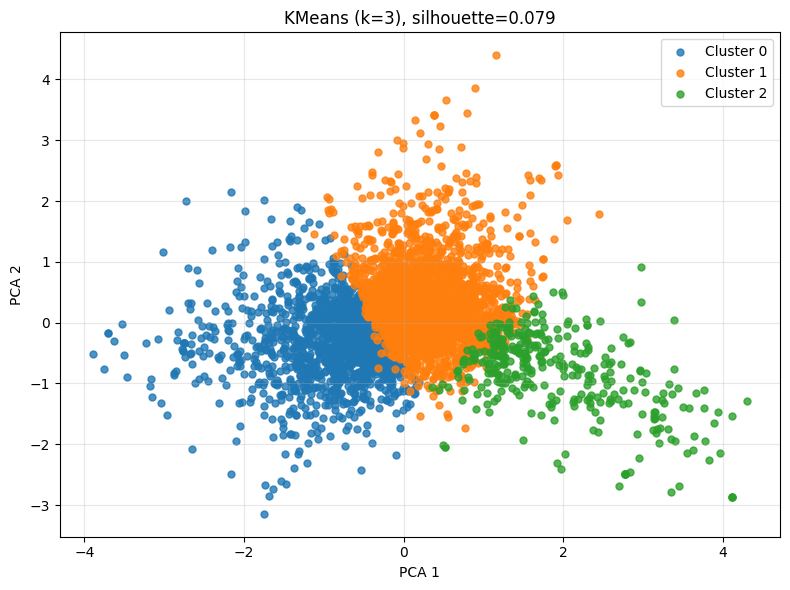

In [4]:
from manager.embedding_manager import EmbeddingManager

manager = EmbeddingManager(
    product_csv_path="../../data/enriched_retail.csv",
    embedding_pkl_path="../../data/products_with_embeddings.pkl",
    milvus_host="localhost", milvus_port="19530", collection_name="products"
)

df_report = manager.attach_behavioral_microsegments(
    reports_csv_path="../../data/customer_reports.csv",
    behavioral_embeddings_pkl="../../data/customer_embeddings.pkl",
    out_csv_path=None,         # aynı dosyanın üstüne yazar
    k=None,                    # en iyi k’yi silhouette ile bulsun
    k_values=range(2, 11),
    return_metrics=False,
    plot=True
)